# <span style="color:purple; font-weight:bold; text-decoration:underline;"> East Asian SO2 Emissions: CEDS 

### <span style="color:purple;"> Imports

In [1]:
import os
import xarray as xr
from matplotlib import pyplot as plt
from scipy.stats import pearsonr

### <span style="color:purple;"> Masking

In [2]:
# Mask to NPAC and strip outside data
NPAC_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/satellite_NPO_binary.nc')
new_mask = NPAC_mask.where(NPAC_mask.lat>20).fillna(0)

### <span style="color:purple;"> Extracting Satellite AOD seasonal climatology

In [3]:
path = '/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/exploratory_analysis/satellite_comparison/Matus_2019_satellite_aerosol_forcing'

satellite_coords = xr.open_dataset(os.path.join(path, 'all-sky_aerosol_forcing_ANN.nc'))

satellite_DJF = xr.open_dataset(os.path.join(path, 'all-sky_aerosol_forcing_DJF.nc'))['AOD_pollution'].transpose('lat', 'lon').assign_coords(lat = satellite_coords['latitude'], lon = satellite_coords['longitude']).where(new_mask, drop=True).mean(dim=['lat', 'lon'])
satellite_MAM = xr.open_dataset(os.path.join(path, 'all-sky_aerosol_forcing_MAM.nc'))['AOD_pollution'].transpose('lat', 'lon').assign_coords(lat = satellite_coords['latitude'], lon = satellite_coords['longitude']).where(new_mask, drop=True).mean(dim=['lat', 'lon'])
satellite_JJA = xr.open_dataset(os.path.join(path, 'all-sky_aerosol_forcing_JJA.nc'))['AOD_pollution'].transpose('lat', 'lon').assign_coords(lat = satellite_coords['latitude'], lon = satellite_coords['longitude']).where(new_mask, drop=True).mean(dim=['lat', 'lon'])
satellite_SON = xr.open_dataset(os.path.join(path, 'all-sky_aerosol_forcing_SON.nc'))['AOD_pollution'].transpose('lat', 'lon').assign_coords(lat = satellite_coords['latitude'], lon = satellite_coords['longitude']).where(new_mask, drop=True).mean(dim=['lat', 'lon'])

seasonal_satellite_AOD_pollution = [satellite_DJF, satellite_MAM, satellite_JJA, satellite_SON]

### <span style="color:purple;"> Putting Model data on satellite grid

In [4]:
model_data = xr.open_dataset('/glade/work/jzweifel/data_2006/h4_concat_2006.nc')['AODSO4dn'].transpose('time', 'lat', 'lon')

# Shift model lon from (0, 360) to (-180, 180)
model_data = model_data.assign_coords(lon = (((model_data.lon + 180) % 360) - 180)).sortby('lon')

model_data_on_sat = model_data.interp(lat=satellite_coords['latitude'], lon=satellite_coords['longitude'], method="linear")

model_DJF = model_data_on_sat.sel(time=model_data_on_sat.time.dt.month.isin([2,3,4])).where(new_mask).mean(dim=['time','lat', 'lon'])
model_MAM = model_data_on_sat.sel(time=model_data_on_sat.time.dt.month.isin([5,6,7])).where(new_mask).mean(dim=['time','lat', 'lon'])
model_JJA = model_data_on_sat.sel(time=model_data_on_sat.time.dt.month.isin([8,9,10])).where(new_mask).mean(dim=['time','lat', 'lon'])
model_SON = model_data_on_sat.sel(time=model_data_on_sat.time.dt.month.isin([11,12,1])).where(new_mask).mean(dim=['time','lat', 'lon'])

seasonal_model_AODSO4dn = [model_DJF, model_MAM, model_JJA, model_SON]

### <span style="color:purple;"> Plotting model vs satellite AOD 

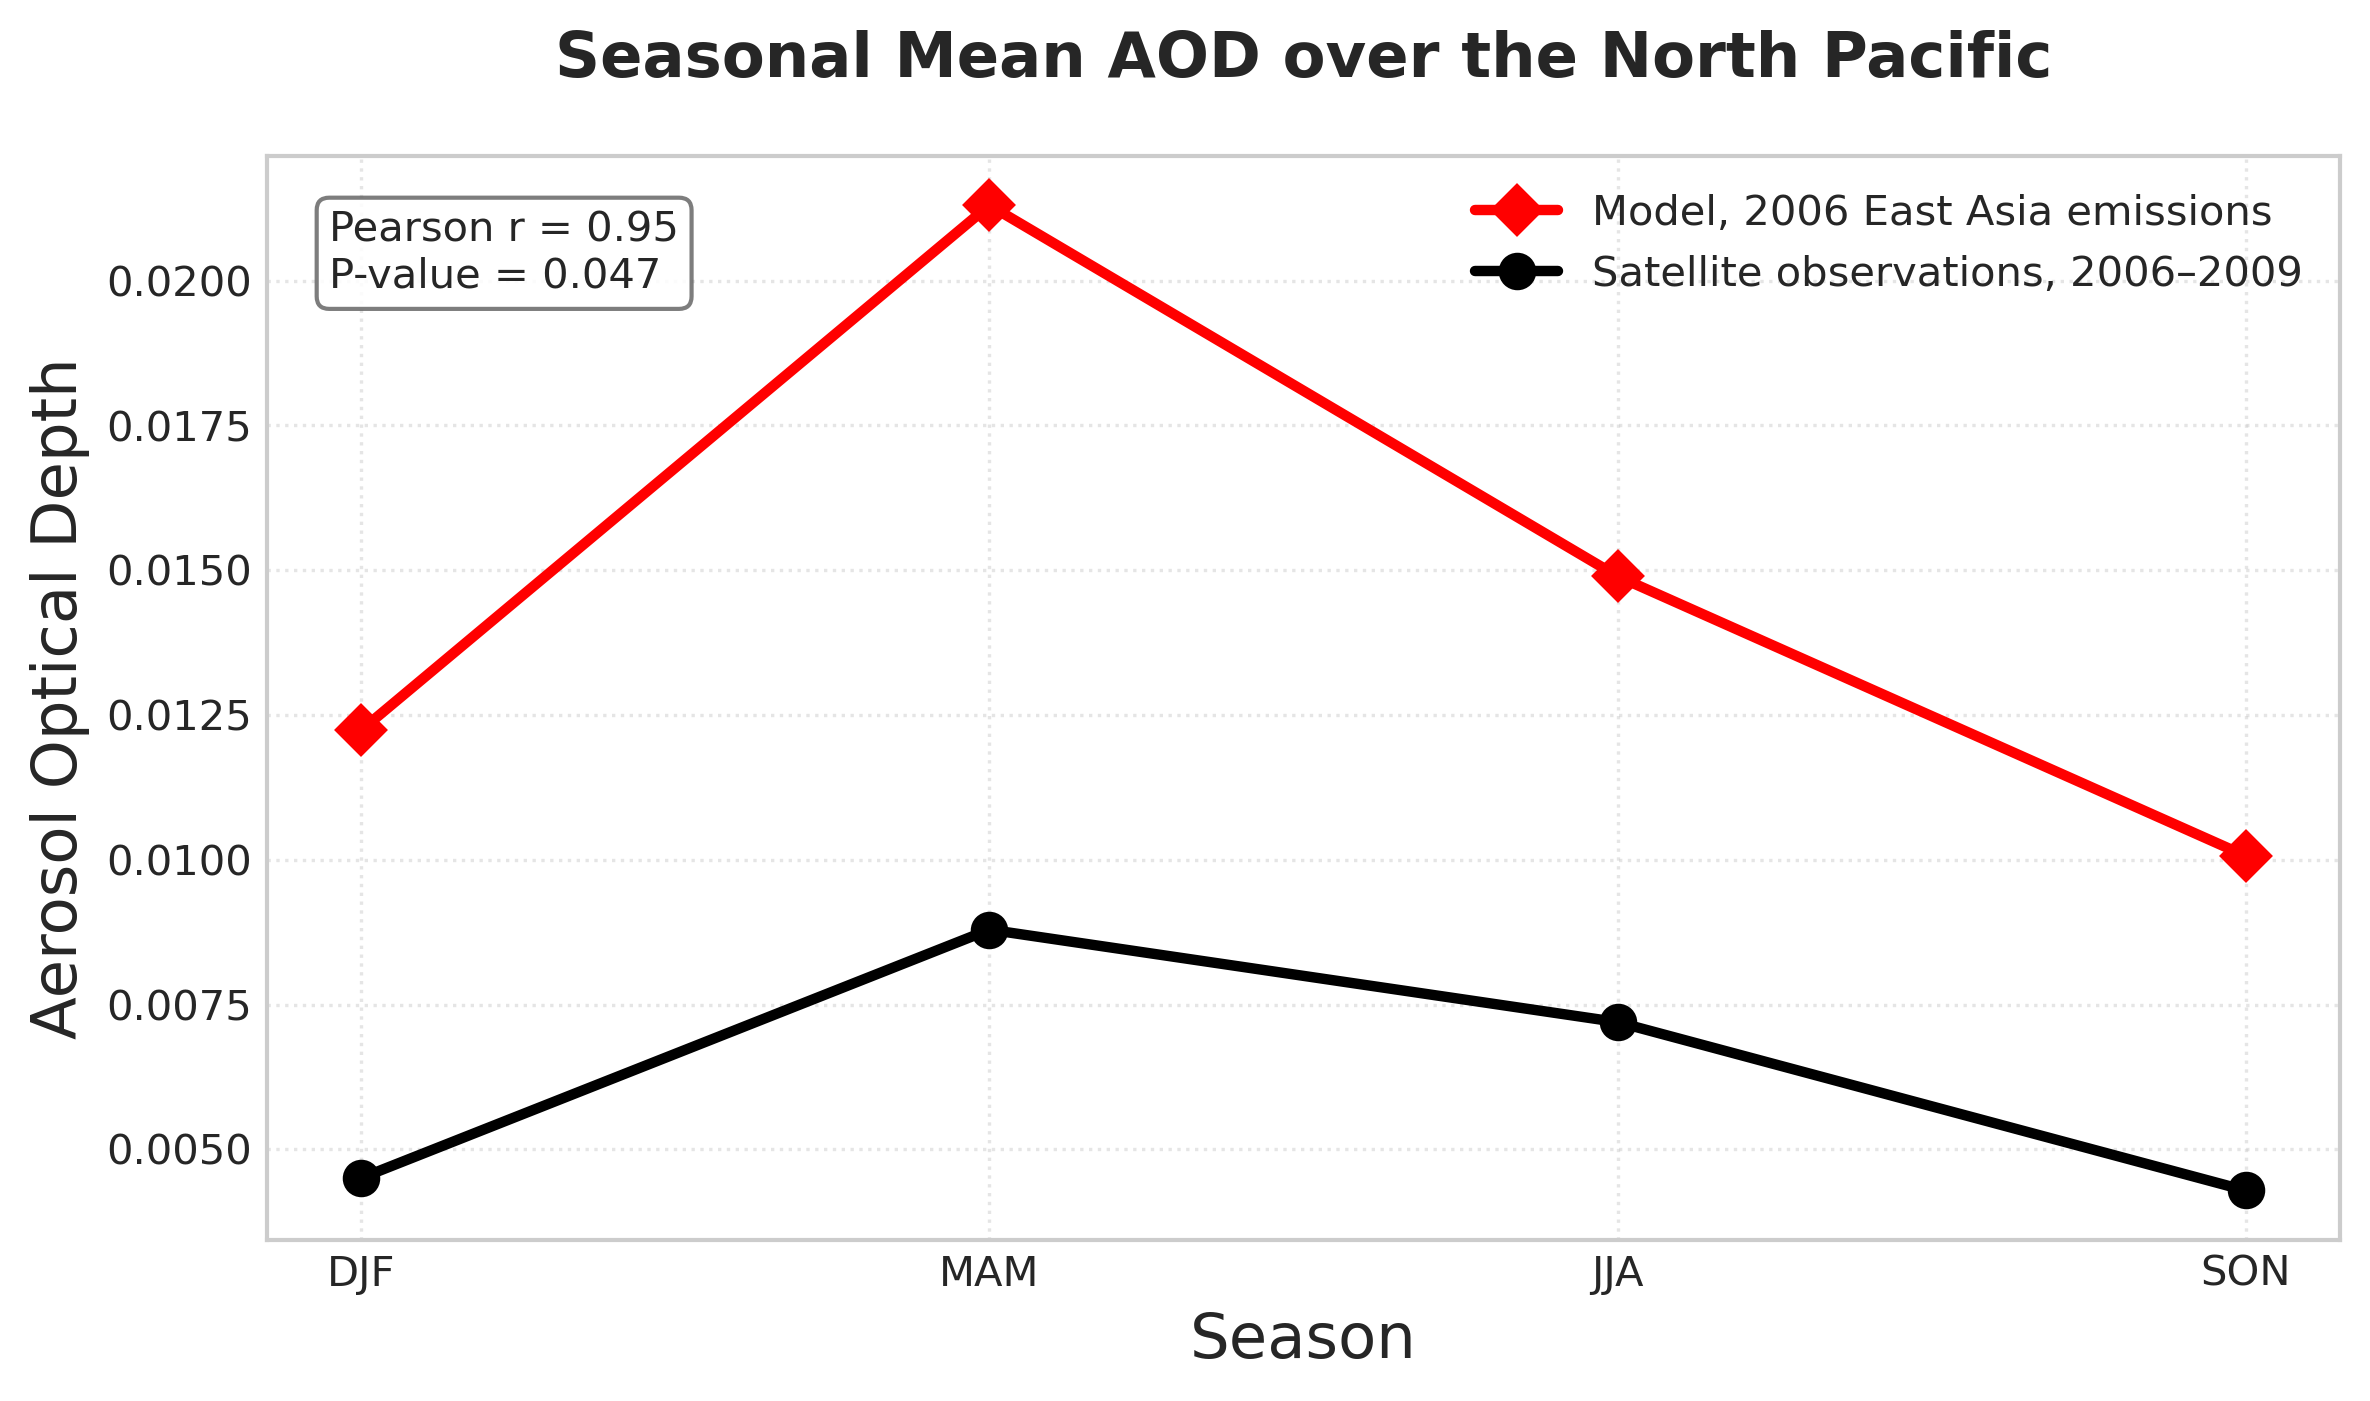

In [6]:
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

# ------------------------------------------------------------
# Global style
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"legend.frameon": False, "lines.linewidth": 2.5, "axes.titleweight": "bold"})

seasons = ["DJF", "MAM", "JJA", "SON"]

model_color = "red"
satellite_color = "black"

# ------------------------------------------------------------
# Stats
# ------------------------------------------------------------
corr_coef, p_value = pearsonr(seasonal_satellite_AOD_pollution, seasonal_model_AODSO4dn)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.plot(seasons, seasonal_model_AODSO4dn, marker="D", markersize=8, color=model_color, label="Model, 2006 East Asia emissions")

ax.plot(seasons, seasonal_satellite_AOD_pollution, marker="o", markersize=8, color=satellite_color, label="Satellite observations, 2006–2009")

ax.set_ylabel("Aerosol Optical Depth", fontsize=15)
ax.set_xlabel("Season", fontsize=15)

ax.set_title("Seasonal Mean AOD over the North Pacific", fontsize=15, y=1.05)

ax.grid(linestyle=":", alpha=0.5)
ax.legend(loc="upper right", fontsize=10)

ax.text(0.03, 0.95, f"Pearson r = {corr_coef:.2f}\nP-value = {p_value:.3f}", transform=ax.transAxes, fontsize=10,
    verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.4", alpha=0.85))

# fig.suptitle("North Pacific Aerosol Optical Depth", fontsize=24, weight="bold", y=1.04)

plt.tight_layout()
plt.subplots_adjust(top=0.84)

plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/saved_figures_pngs/Figure_S2.png')

plt.show()